<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 8. Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** _номер варианта или значение SEED_

### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 1 | 42 | 16 | 1.5 | углы 0–32° с шагом 8° |
| 2 | 7 | 16 | 2.0 | углы 0–40° с шагом 10° |
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |
| 4 | 2024 | 20 | 2.2 | углы 0–32° с шагом 8° |
| 5 | 314 | 12 | 1.2 | углы 0–40° с шагом 10° |
| 6 | 555 | 24 | 1.8 | углы 0–24° с шагом 6° |

> Вариант выдаётся преподавателем. Все числовые результаты в отчёте должны соответствовать
> **вашему** варианту, а не значениям из примера.

### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

### Задачи

1. Построить учебный стенд компьютерного зрения и измерить базовую точность.
2. Реализовать имитацию физического канала наблюдения и оценить влияние отдельных факторов съёмки.
3. Исследовать локальность патча: зависимость деградации от площади и положения области.
4. Применить логику Expectation over Transformation при оценке устойчивости.
5. Построить карту качества жёсткого объекта в координатах «дистанция × ракурс».
6. Смоделировать не-жёсткие деформации ткани и сравнить их с жёстким преобразованием.
7. Обучить модель с физически правдоподобными аугментациями и оценить прирост устойчивости.
8. Проверить эффект временной агрегации решений по кадрам.
9. Сформулировать выводы и заполнить сводную таблицу отчёта.

### Ограничение

Работа выполняется **только** на синтетическом учебном наборе и локальных моделях. Запрещается
использовать код работы для воздействия на реальные системы восприятия, камеры, внешние сервисы
и любые эксплуатируемые объекты. Печатаемые атакующие шаблоны в работе не создаются.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

$
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}},
$

где $M$ — маска области патча, $p$ — его содержимое, $T_\theta$ — преобразование при параметрах
съёмки $\theta$ (ракурс, дистанция, освещение, оптика, обработка изображения).

Требование робастности возмущения формализует Expectation over Transformation:

$
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big].
$

**Задание 0.** Заполните таблицу различий трёх постановок (ячейки со знаком «?»):

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | Все пиксели изображения | Локальная область на плоской поверхности знака | Текстура ткани на непостоянном окружении |
| Ограничение возмущения | возмущение меньше epsilon | Площадь и форма патча, палитра, положение на знаке | Площадь, положение на теле, растяжимость материала|
| Обязательные члены $\mathcal{D}$ | Поворот, масштаб, яркость, контрастность, размытие, шум | перспектива, положение на знаке, освещение, калибровка принтера | нежёсткие деформации, поза, динамика движения |
| Основная сложность | Найти направление градиента | 	Напечатать оптимизированные цвета и учесть геометрию съёмки | Смоделировать деформацию ткани и видеодинамику, сохранить эффект при движении |
| Типичная метрика | ASR, L2, Linf, L0 | ASR, robust ASR | ASR, mAP детектора, устойчивость |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [ ]:
# TODO A.1: подставьте значения своего варианта из таблицы вариантов
SEED = 555   # например 42
RES = 24    # например 16
FREQ = 2.8   # например 1.5

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"

RES = 24×24 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.959


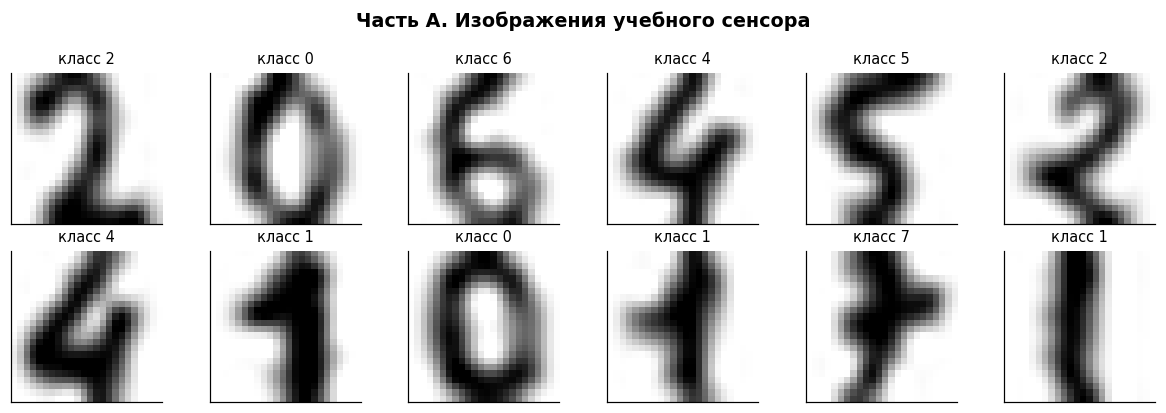

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

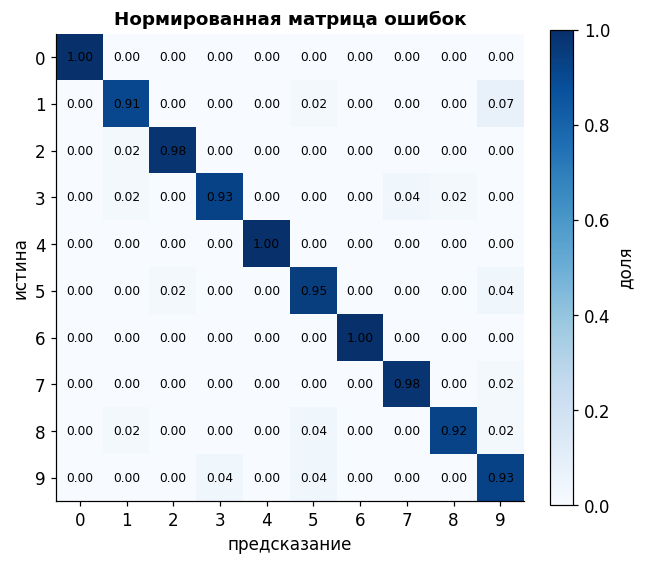

In [ ]:
# TODO A.3: постройте нормированную матрицу ошибок базовой модели.
# Подсказка: confusion_matrix(..., normalize="true"), затем imshow с colorbar.

cm = confusion_matrix(y_test, baseline.predict(flat(X_test_img)), normalize="true")

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказание"); ax.set_ylabel("истина")
ax.set_title("Нормированная матрица ошибок")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, label="доля")
plt.tight_layout(); plt.show()

**Отчёт по части A.** Заполните:

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` | 555/24|
| Размер обучающей выборки | 1257|
| Базовая точность `acc_clean` | 0.959|
| Две пары классов с наибольшей путаницей |1 и 9 |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: Нет, нельзя. acc_clean измеряется на неискажённых тестовых изображениях, взятых из того же распределения, что и обучающая выборка. Но физическая камера формирует совсем другой вход: ракурс, дистанция, освещение, размытие оптики, шум сенсора и окклюзии сдвигают распределение настолько, что модель оказывается вне зоны, на которой обучалась

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [ ]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [ ]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # поворот и масштаб уже реализованы
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # TODO B.1: контраст относительно середины диапазона: (out - 0.5) * contrast + 0.5
    # TODO B.2: яркость: умножение на brightness
    # TODO B.3: размытие оптики: gaussian_filter(out, sigma=blur), если blur > 0
    # TODO B.4: шум сенсора: прибавьте gen.normal(0, noise, out.shape), если noise > 0
    # TODO B.5: окклюзия: occlusion = (r0, r1, c0, c1, value) -> присвоить value этому окну
    out = (out - 0.5) * contrast + 0.5
    out = out * brightness
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)
    if noise > 0:
        out = out + gen.normal(0, noise, out.shape)
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out[r0:r1, c0:c1] = value

    return np.clip(out, 0.0, 1.0).astype(np.float32)



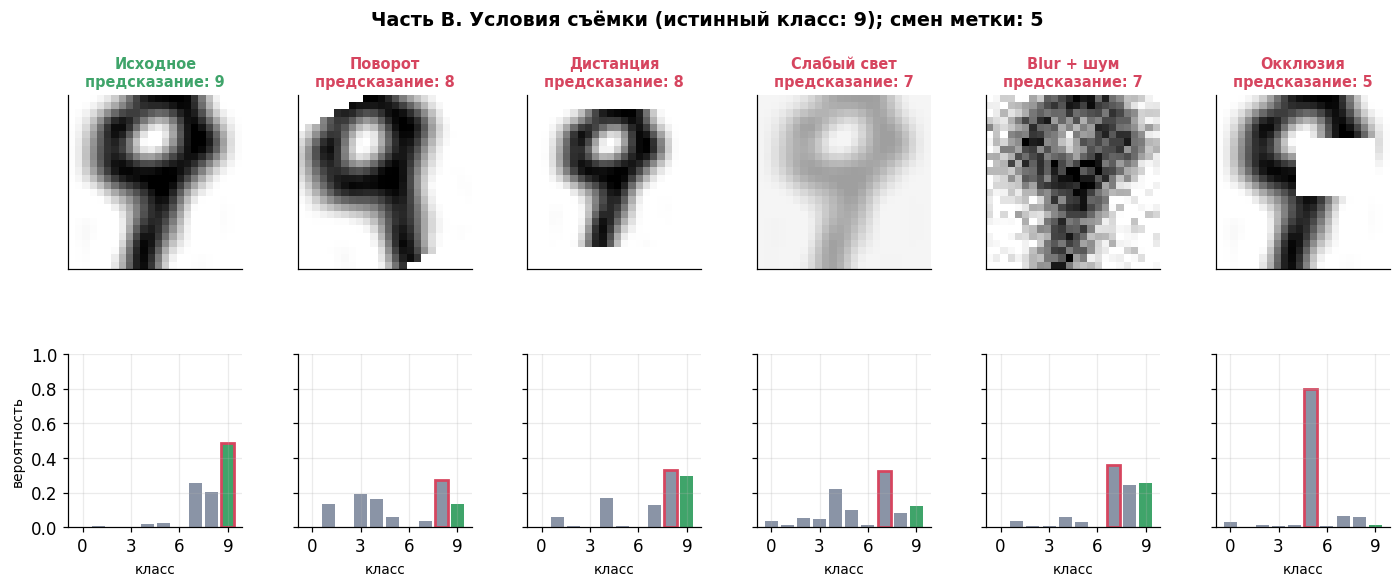

B.7 Число режимов со сменой метки: 5 (требуется не менее 2)


In [ ]:
# TODO B.6: выберите объект-пример и подберите параметры так, чтобы МИНИМУМ два режима
# приводили к смене предсказанной метки. Значения ниже — стартовые, их нужно изменить.
idx = 13
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",        dict()),
    ("Поворот",         dict(angle=26)),
    ("Дистанция",       dict(scale=0.80)),
    ("Слабый свет",     dict(brightness=0.42, contrast=0.80)),
    ("Blur + шум",      dict(blur=1.7, noise=0.13)),
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3, RES // 2 - 1, RES - 2, 0.0))),
]

fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
flips = 0
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                           color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

**Отчёт по части B.** Заполните таблицу по своим значениям:

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное | 9| 0,5| нет|
| Поворот | 8| 0,15| да|
| Дистанция | 8| 0,3| да|
| Слабый свет | 7| 0,15| да|
| Blur + шум | 7| 0,27| да|
| Окклюзия | 5| 0,01| да|

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: В моем примере больший урон нанесла окклюзия. В других примерах предсказание и вероятность истинного класса разнятся по каждому из изменений входного изображения

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [40]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3)
    # TODO C.1: скопируйте изображение, впишите значение value в окно
    # [top:top+size, left:left+size] и постройте маску той же формы
    result = image.copy()
    result[top:top + size, left:left + size] = value
    mask = np.zeros_like(image)
    mask[top:top + size, left:left + size] = 1.0
    return result, mask

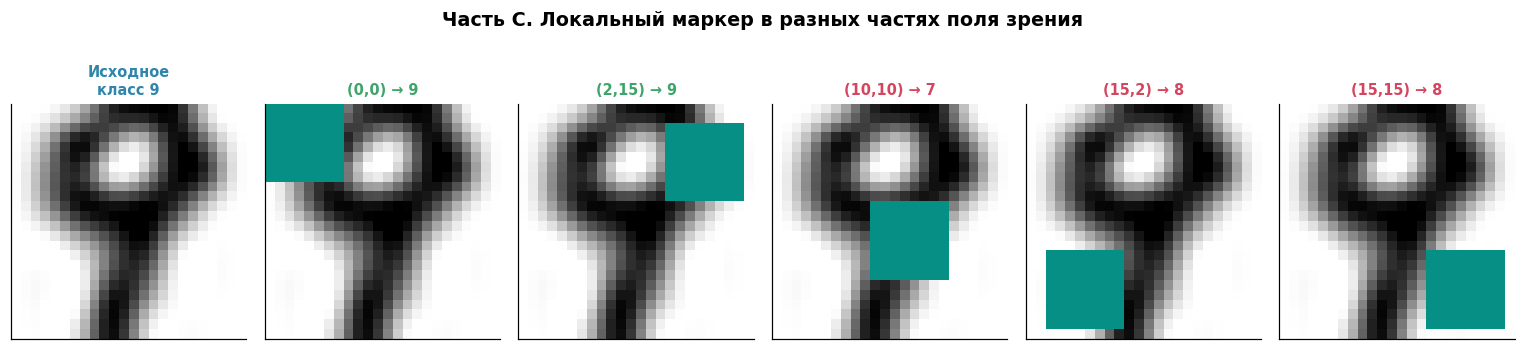

In [41]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [22]:
# TODO C.2: заполните карту точности pos_map по позициям маркера на всей тестовой выборке.
# TODO C.3: заполните списки area_acc и area_frac для кривой деградации по площади.

stride = max(1, RES // 8)
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        marked = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked)))

sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    if s == 0:
        area_acc.append(acc_clean)
    else:
        top = left = (RES - s) // 2
        marked = np.asarray([apply_marker(im, top, left, s)[0] for im in X_test_img])
        area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked))))
    area_frac.append(100 * s * s / RES ** 2)

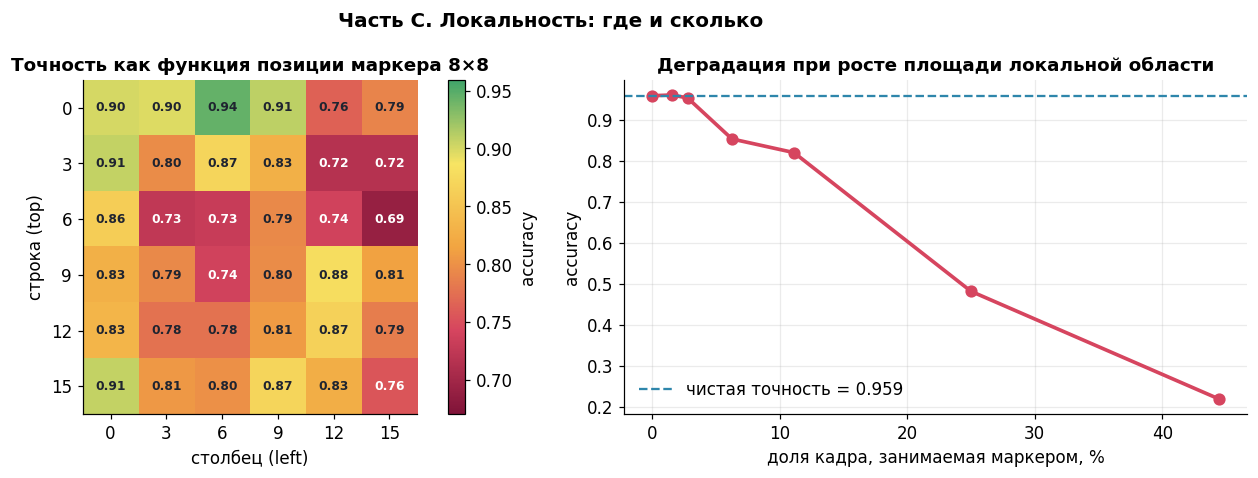

C.4 Худшая позиция: (6, 15) → accuracy 0.691
C.5 Лучшая позиция: accuracy 0.944; разница 0.254


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

**Отчёт по части C.**

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 8|
| Худшая позиция и её accuracy | (6,15) , acc 0.69|
| Лучшая позиция и её accuracy | (0,6), acc 0.94 |
| Разница между худшей и лучшей позицией | 0.25|
| Площадь, при которой accuracy падает ниже 0.5, % | 25% |

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: информативность разных областей изображения неодинакова. Логистическая регрессия обучается на пиксельных интенсивностях, и веса её коэффициентов для пикселей, где обычно находятся штрихи цифры (центр, верхняя половина), значительно выше, чем для краев изображения. Маркер, наложенный в центр, попадает в зону с большими по модулю весами и резко меняет логиты.

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [26]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    # TODO D.1: верните словарь с ключами angle, scale, brightness, contrast, blur, noise.
    # Ориентировочные диапазоны при severity = 1:
    #   angle ±17°, scale 0.83–1.13, brightness 0.74–1.20,
    #   contrast 0.80–1.20, blur 0–0.85, noise 0–0.055
    return dict(
        angle=gen.uniform(-17, 17) * severity,
        scale=1.0 + gen.uniform(-0.17, 0.13) * severity,
        brightness=1.0 + gen.uniform(-0.26, 0.20) * severity,
        contrast=1.0 + gen.uniform(-0.20, 0.20) * severity,
        blur=max(0.0, gen.uniform(0, 0.85) * severity),
        noise=max(0.0, gen.uniform(0, 0.055) * severity),
    )


def transformed_dataset(imgs, gen, severity=1.0):
    # TODO D.2: примените physical_transform со случайными параметрами к каждому изображению
    out = []
    for im in imgs:
        params = sample_params(gen, severity)
        out.append(physical_transform(im, **params, generator=gen))
    return np.asarray(out)

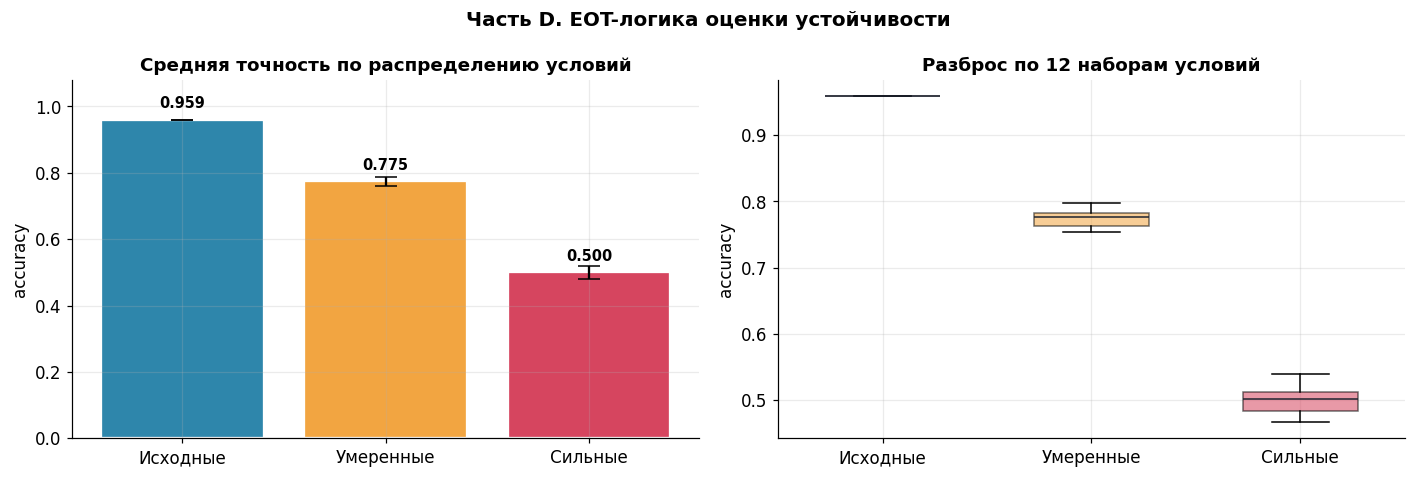

D.3 Исходные   accuracy = 0.959 ± 0.000
D.3 Умеренные  accuracy = 0.775 ± 0.013
D.3 Сильные    accuracy = 0.500 ± 0.020


In [27]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.959| 0.0| 0.0|
| Умеренные | 0.775| 0.013| 0.184|
| Сильные | 0.5| 0.02| 0.459|

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ: Один кадр — это одна точка из распределения условий. Модель может случайно «повезти»: поворот окажется благоприятным, blur не попадёт в критическую зону, шум будет умеренным. Оценка по одному кадру игнорирует весь остальной диапазон. Усреднение по EOT даёт честную картину, потому что включает и «лёгкие», и «трудные» углы. Рост severity расширяет диапазон условий, поэтому растёт дисперсия

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [28]:
# TODO E.1: задайте углы согласно своему варианту
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 6, 12, 18, 24]   # замените на углы своего варианта

# TODO E.2: заполните матрицу grid: строки — углы, столбцы — масштабы
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([
            physical_transform(im, angle=a, scale=s, brightness=0.95,
                               blur=0.25, generator=gen)
            for im in X_test_img
        ])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

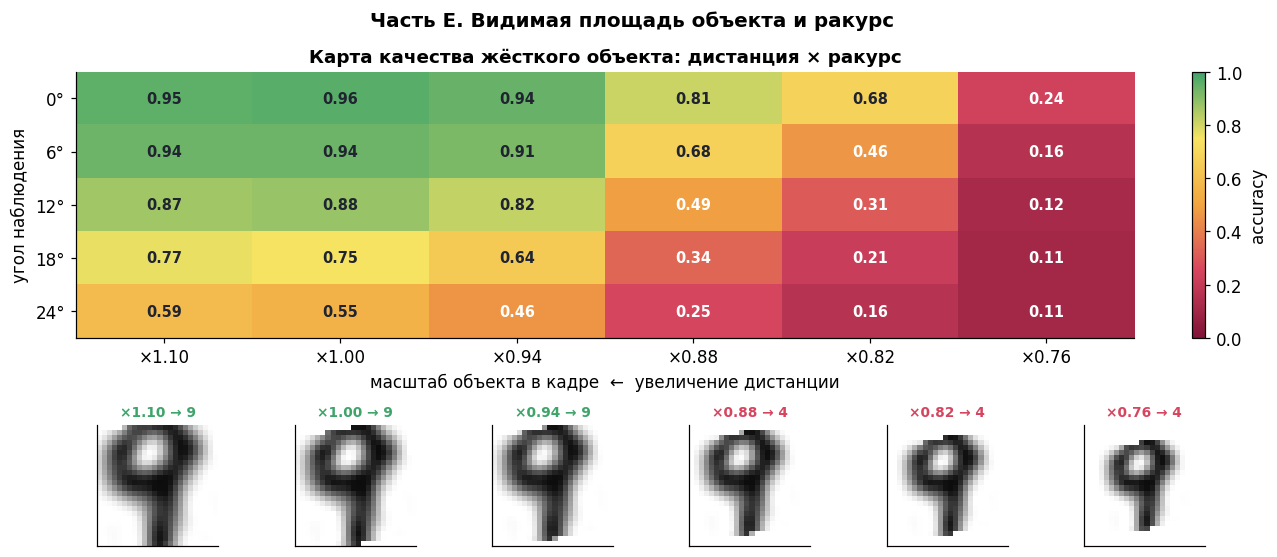

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     6°: ×1.10, ×1.00, ×0.94
    12°: ×1.10, ×1.00, ×0.94
    18°: ×1.10, ×1.00
    24°: нет


In [29]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

**Отчёт по части E.**

| Показатель | Ваше значение |
|---|---|
| Углы варианта | 0 6 12 18 24|
| Максимальная accuracy в карте | 0.96|
| Минимальная accuracy в карте | 0.11|
| Наибольший допустимый угол при accuracy ≥ 0.70 | 18|
| Наименьший допустимый масштаб при accuracy ≥ 0.70 | 0.88|

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ: Чем меньше объект занимает пикселей в кадре, тем меньше информации доступно модели и тем легче её обмануть. Плюс при малом масштабе blur и шум сильнее размывают оставшиеся детали. Это видно на карте: accuracy падает в правом нижнем углу.  
Атака на классификатор проще: достаточно изменить одну метку. Атака на детектор сложнее: нужно одновременно нарушить локализацию, классификацию и подавление NMS. Это три задачи вместо одной, и каждая требует своего механизма.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [30]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    # TODO F.1: поле смещений по столбцам: amplitude * sin(2*pi*frequency*rr/h + phase)
    # TODO F.2: поперечное поле по строкам с коэффициентом 0.45
    # TODO F.3: примените map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [31]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

# TODO F.4: заполните warp_acc (деформация ткани) и rigid_acc (жёсткий поворот на a * 6 градусов)
warp_acc, rigid_acc = [], []
for a in amps:
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))
    rigid = np.asarray([physical_transform(im, angle=a * 6) for im in X_test_img])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rigid))))

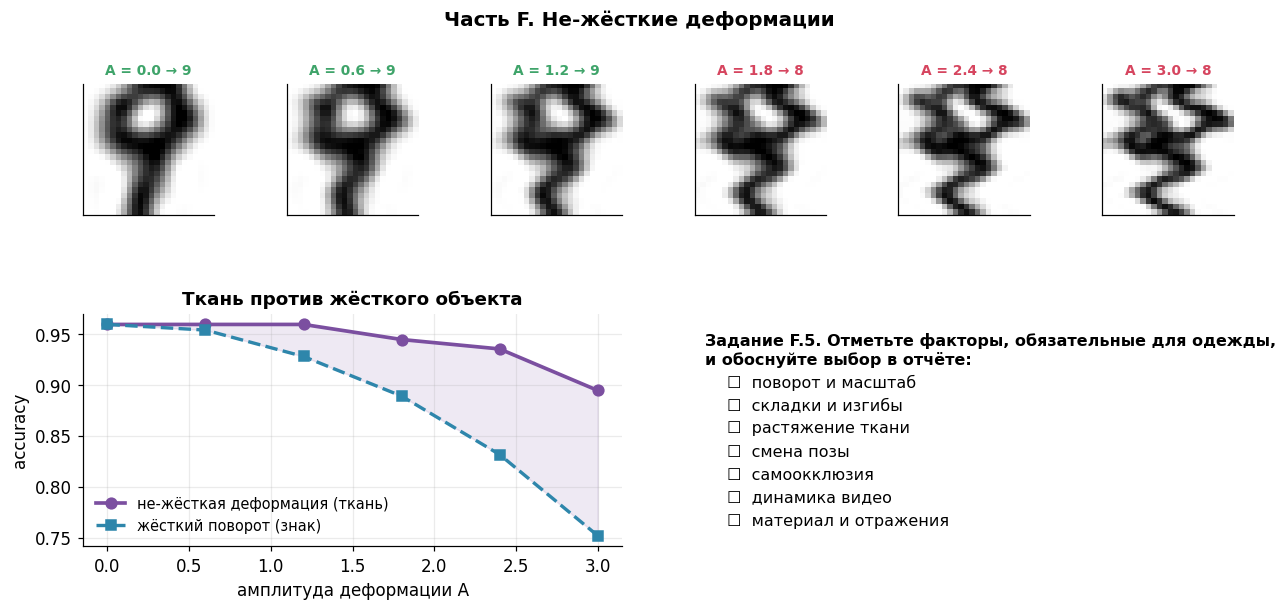

F.6 accuracy при максимальной деформации: ткань 0.894 против жёсткого поворота 0.752


In [32]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

**Отчёт по части F.**

| A | accuracy (ткань) | accuracy (жёсткий поворот) | Разница |
|---|---|---|---|
| 0.0 |0.96 | 0.96| 0.0|
| 1.2 | 0.96| 0.925| 0.035|
| 2.4 | 0.94| 0.84| 0.1|
| 3.0 | 0.894| 0.752| 0.142|

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении $\mathcal{D}$ по сравнению со знаком?

Ответ: Ткань — не жёсткая поверхность. Она деформируется неравномерно: появляются складки, растяжения, изгибы. Жёсткий поворот эти деформации не описывает. В распределении D для одежды добавляются члены, которых нет у знака: (1) не-жёсткие деформации (TPS или поля смещений), (2) изменение позы — человек наклоняется, поднимает руки, (3) самоокклюзия — руки, волосы, предметы перекрывают часть патча, (4) временная динамика видео. Дополнительно важны свойства материала: отражения, растяжение. Всё это делает атаку на одежду существенно сложнее и хуже переносится из цифрового мира в физический.

## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [33]:
# TODO G.1: сформируйте аугментированную выборку: исходные данные + 4 копии со случайными
# условиями съёмки (severity ≈ 1.3) + 1 копия с деформацией ткани (amplitude 0.5–2.5).
aug_gen = np.random.default_rng(SEED + 5)
X_aug_list = [X_train_img]
y_aug_list = [y_train]

# TODO G.2: обучите модель robust с теми же гиперпараметрами, что у baseline
for _ in range(4):
    X_aug_list.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))
    y_aug_list.append(y_train)

warped_train = np.asarray([
    cloth_warp(im, amplitude=float(aug_gen.uniform(0.5, 2.5)))
    for im in X_train_img
])
X_aug_list.append(warped_train)
y_aug_list.append(y_train)

X_aug = np.concatenate(X_aug_list, axis=0)
y_aug = np.concatenate(y_aug_list, axis=0)

robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

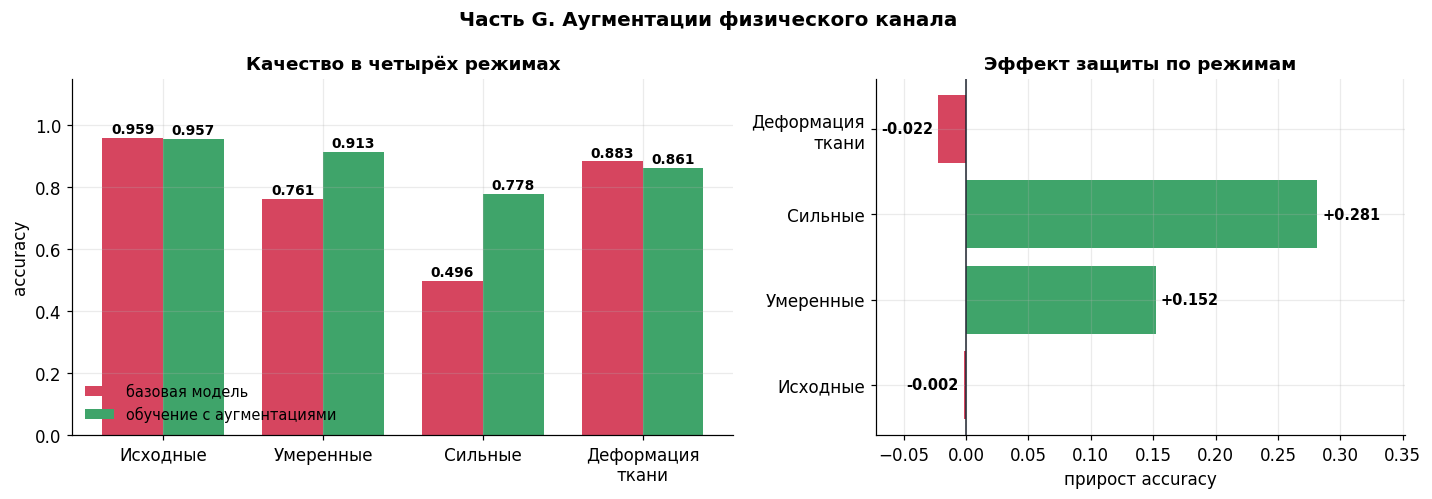

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.959 → защита 0.957 (-0.002)
    Умеренные          база 0.761 → защита 0.913 (+0.152)
    Сильные            база 0.496 → защита 0.778 (+0.281)
    Деформация ткани   база 0.883 → защита 0.861 (-0.022)


In [34]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

**Отчёт по части G.**

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
| Исходные | 0.959| 0.957| -0.002|
| Умеренные | 0.761| 0.913| 0.152|
| Сильные | 0.496| 0.778| 0.282|
| Деформация ткани | 0.883| 0.861| -0.022|

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ: Цена робастности в данном эксперименте оказалась минимальной: потеря на чистых данных составила всего 0.002
Такой компромисс возникает потому, что модель, обученная на аугментированных данных, вынуждена искать более «гладкую» и широкую решающую границу, устойчивую к шумам, размытию и искажениям. Это заставляет её тратить часть своей ёмкости на обобщение вместо идеальной подгонки под чистые пиксели исходного распределения.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [35]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# TODO H.1: сформируйте кадры: случайные условия severity ≈ 1.3, а на кадрах 9–14 добавьте окклюзию.
# TODO H.2: соберите probas (вероятности по кадрам) и per_frame_pred (покадровые решения).
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, severity=1.3)
    if 9 <= t <= 14:
        params["occlusion"] = occ_window
    frame = physical_transform(example, **params, generator=seq_gen)
    frames.append(frame)
    p = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(p)
    per_frame_pred.append(int(np.argmax(p)))
probas = np.asarray(probas)
# TODO H.3: вычислите накопленные решения cum_pred и уверенность cum_conf по средним вероятностям
cum_pred = [int(np.argmax(probas[:t + 1].mean(axis=0))) for t in range(FRAMES)]
cum_conf = [probas[:t + 1].mean(axis=0)[true_label] for t in range(FRAMES)]
per_frame_conf = [probas[t][true_label] for t in range(FRAMES)]

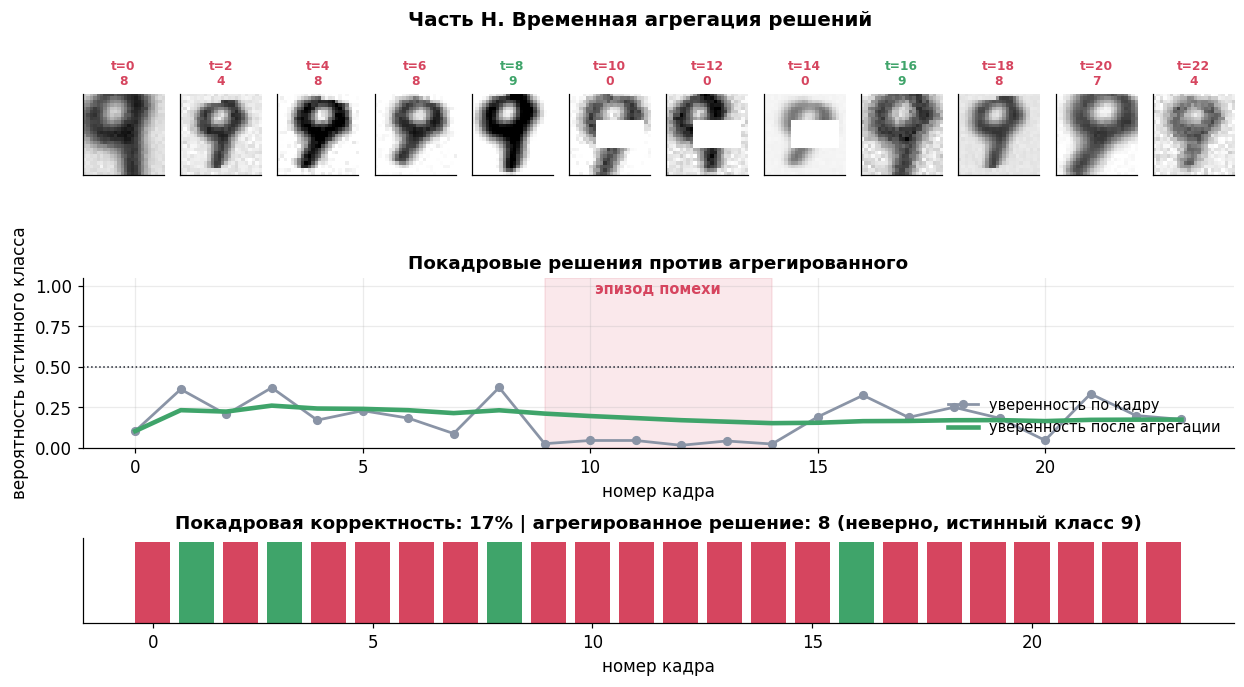

H.4 Покадровая корректность: 0.167
H.5 Агрегированное решение: 8 (истинный класс 9)
H.6 Агрегация стабильно верна начиная с кадра: None


In [36]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])
    ok = per_frame_pred[t * 2] == true_label
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")
fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

**Отчёт по части H.**

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров | 0.167|
| Итоговое агрегированное решение | 8|
| Номер кадра, с которого агрегация стабильно верна | null|

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

Ответ: _______________________________________________

## Часть I. Итоговый анализ

### Сводная таблица результатов

Заполните по результатам своего варианта:

| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
| Идеальные условия | 0,959| — | |
| Умеренные условия | 0,761| 0,198| |
| Сильные условия | 0,496| | 0,463|
| Локальный маркер, худшая позиция | 0,69| 0,269| |
| Максимальная дистанция и ракурс | 0,11| 0,849| |
| Максимальная деформация ткани | 0,859| 0,1| |
| Аугментации, сильные условия | 0,778| 0,181| |
| Агрегация кадров |0,167 | 0,792| |

### Выводы

Сформулируйте не менее пяти выводов, опираясь на числа из своих экспериментов:

1. Высокая точность на чистых данных не гарантирует устойчивость к физическим условиям
2. Позиция локального маркера критична
3. При росте площади маркера деградация нелинейна
4. Обучение с физически правдоподобными аугментациями повышает устойчивость в сильных условиях
5. Временная агрегация решений может быть провальной без должного предобучения модели на измененных входных данных
### Контрольные вопросы

1. Почему ограничение $\|\delta\|_p \le \varepsilon$ недостаточно для описания физической атаки?

Потому что оно описывает возмущение на уровне пикселей и не учитывает физические преобразования: ракурс, дистанцию, освещение, размытие, шум и т.д

2. Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?  
ASR — доля атак, сменивших метку в одной конфигурации. R-ASR — ASR, усреднённый по распределению условий. R-ASR обычно ниже, потому что патч, оптимизированный под один ракурс, может не сработать в другом

3. Как площадь и положение патча влияют на его эффективность? Приведите числа из части C.

Наиболее эффективны маркеры в центре, где сосредоточены информативные пиксели. Чем больше площадь патча, тем больше шанс ошибочного предсказания модели

4. Почему атака на детектор объектов сложнее атаки на классификатор?  
Атака на детектор сложнее: классификатор возвращает одну метку, детектор — множество рамок с классами и confidence после NMS. Нужно нарушить одновременно локализацию (IoU < порога), классификацию и подавление NMS. Это три задачи вместо одной.
5. Какие члены распределения $\mathcal{D}$ обязательны для одежды и не нужны для жёсткого знака?  
Для одежды обязательны: не-жёсткие деформации, поза, самоокклюзия, динамика видео. Для жёсткого знака они не нужны — знак плоский и статичный. Дополнительно для одежды важны свойства материала (отражения, растяжение)
6. Почему временная агрегация помогает, но не является полной защитой?   
Временная агрегация сглаживает одиночные ошибки, но не защищает от длительных помех: если эпизод перекрывает большинство кадров, агрегированное решение тоже сбивается
7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?   
Цену робастности измеряют как разницу accuracy на чистых данных между базовой и защищённой моделью. Одним режимом ограничиваться нельзя: защита, выигрывающая при сильных искажениях, может проиграть на чистых данных или в умеренных условиях.

### Дополнительные задания повышенной сложности (кому интересно)

- Заменить `LogisticRegression` на `MLPClassifier` и повторить части D, E, G. Изменился ли характер деградации?
- Добавить в часть C маркер несимметричной формы (полоса) и сравнить с квадратом равной площади.
- Добавить в `cloth_warp` второе поперечное поле смещений с независимой частотой.
- Прогнать работу для двух дополнительных значений `SEED` и оценить устойчивость выводов.
- Реализовать простейший детектор аномальной локальной области и проверить его на данных части C.

### Чек-лист сдачи

- [ ] Заполнен паспорт работы и указан номер варианта.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях B, C, D, E, F, G, H.
- [ ] В части B достигнуто не менее двух смен предсказанной метки.
- [ ] Заполнены все таблицы отчёта числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–7.
- [ ] Сформулировано не менее пяти выводов.
- [ ] Все графики подписаны и читаемы.


### Литература

- Brown T. et al. Adversarial Patch (2017): <https://arxiv.org/abs/1712.09665>
- Eykholt K. et al. Robust Physical-World Attacks on Deep Learning Visual Classification (2018): <https://arxiv.org/abs/1707.08945>
- Athalye A. et al. Synthesizing Robust Adversarial Examples (2018): <https://arxiv.org/abs/1707.07397>
- Xu K. et al. Adversarial T-shirt! Evading Person Detectors in a Physical World (2020): <https://arxiv.org/abs/1910.11099>
- Thys S. et al. Fooling automated surveillance cameras (2019): <https://arxiv.org/abs/1904.08653>